In [68]:
import kagglehub

path = kagglehub.dataset_download("kunshbhatia/delhi-air-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/delhi-air-quality-dataset


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [70]:
df = pd.read_csv("/kaggle/input/delhi-air-quality-dataset/final_dataset.csv")
df.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [71]:
df.tail()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
1456,27,12,2024,0,5,58.43,249.17,41.69,65.89,0.99,36.25,263
1457,28,12,2024,0,6,33.83,150.77,33.31,66.14,0.79,35.19,113
1458,29,12,2024,1,7,31.21,139.75,27.01,65.94,0.57,35.88,142
1459,30,12,2024,0,1,38.01,152.83,29.12,65.16,0.55,38.38,116
1460,31,12,2024,0,2,80.42,318.96,40.37,64.98,0.84,39.93,209


In [72]:
df.shape

(1461, 12)

In [73]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


In [74]:
df.isnull().sum()

Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
Ozone             0
AQI               0
dtype: int64

In [75]:
df.duplicated().sum()

0

In [76]:
df = df.drop(columns=['Date'])




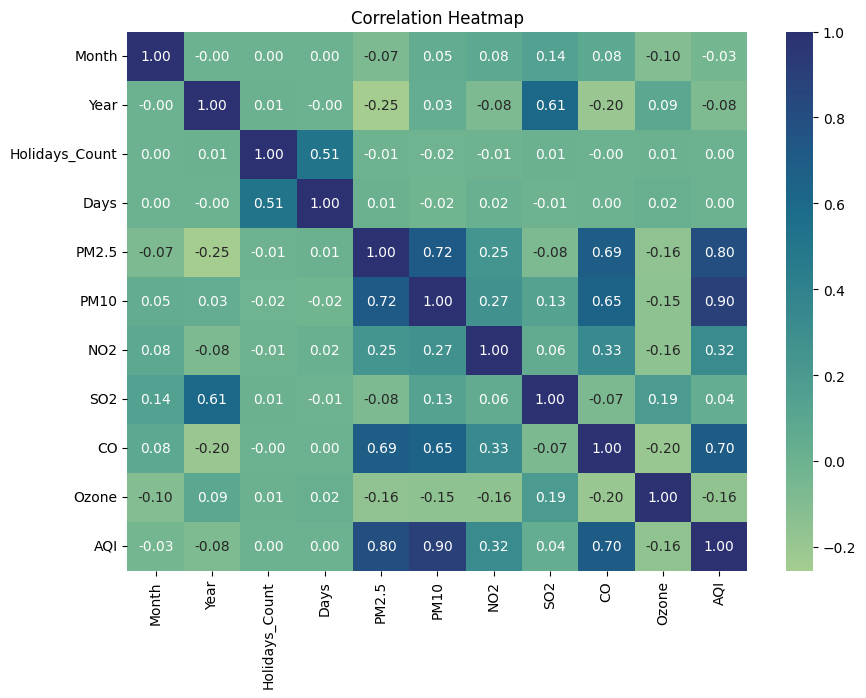

In [77]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="crest")
plt.title("Correlation Heatmap")
plt.show()


In [78]:
X = df.drop(columns=['AQI'])
y = df['AQI']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [80]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [81]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


Ridge()

In [82]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)


Lasso(alpha=0.01)

In [83]:
models = {"Linear": lr, "Ridge": ridge, "Lasso": lasso}

for name, model in models.items():
    pred = model.predict(X_test)
    print(name)
    print("R2 Score:", r2_score(y_test, pred))
    print("RMSE:", mean_squared_error(y_test, pred, squared=False))
    print("-"*40)

Linear
R2 Score: 0.881862861253456
RMSE: 39.15380264394348
----------------------------------------
Ridge
R2 Score: 0.8818796778004485
RMSE: 39.15101581838503
----------------------------------------
Lasso
R2 Score: 0.8818907972773133
RMSE: 39.14917299806265
----------------------------------------


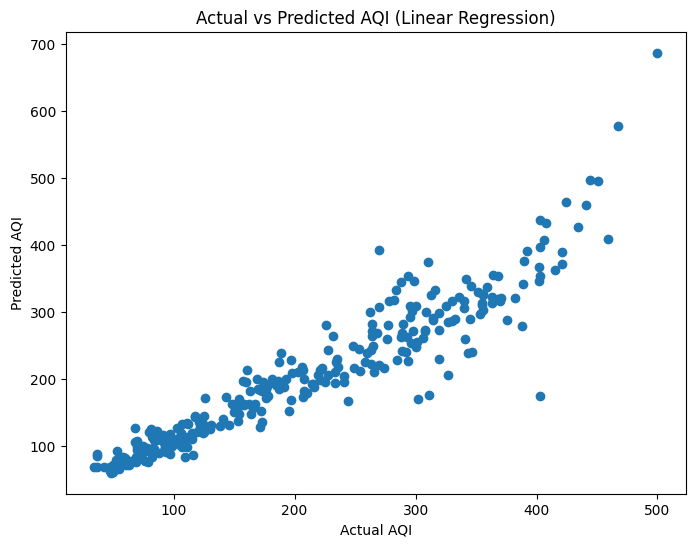

In [84]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr.predict(X_test)) 
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Linear Regression)")
plt.show()


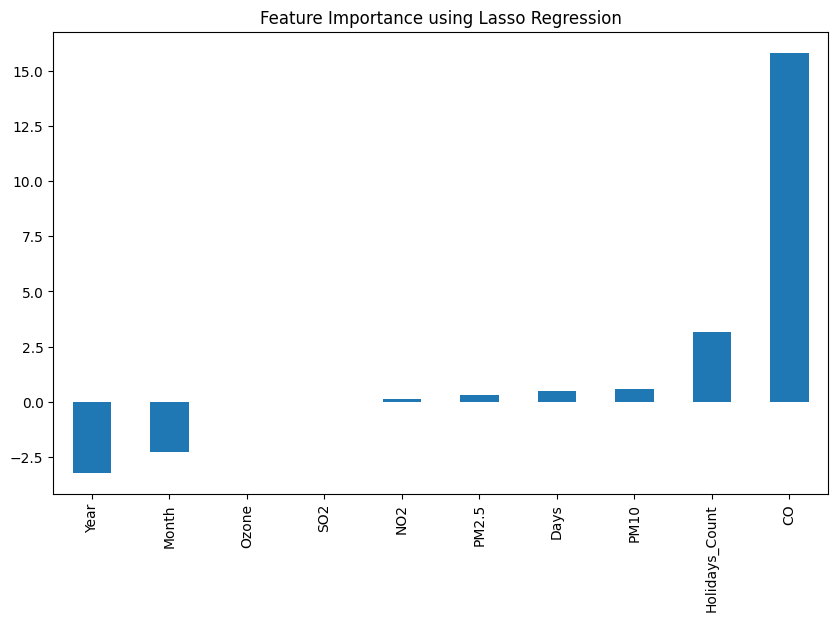

In [85]:
importance = pd.Series(lasso.coef_, index=X.columns)
importance.sort_values().plot(kind='bar', figsize=(10,6))
plt.title("Feature Importance using Lasso Regression")
plt.show()


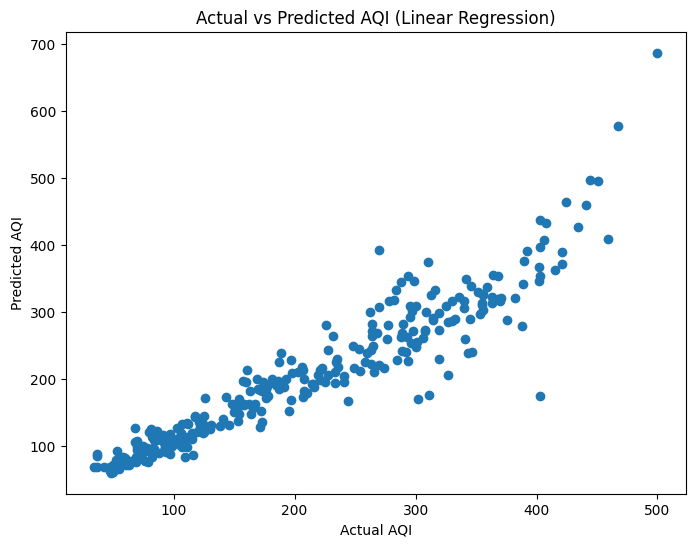

In [86]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr.predict(X_test))
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Linear Regression)")
plt.show()


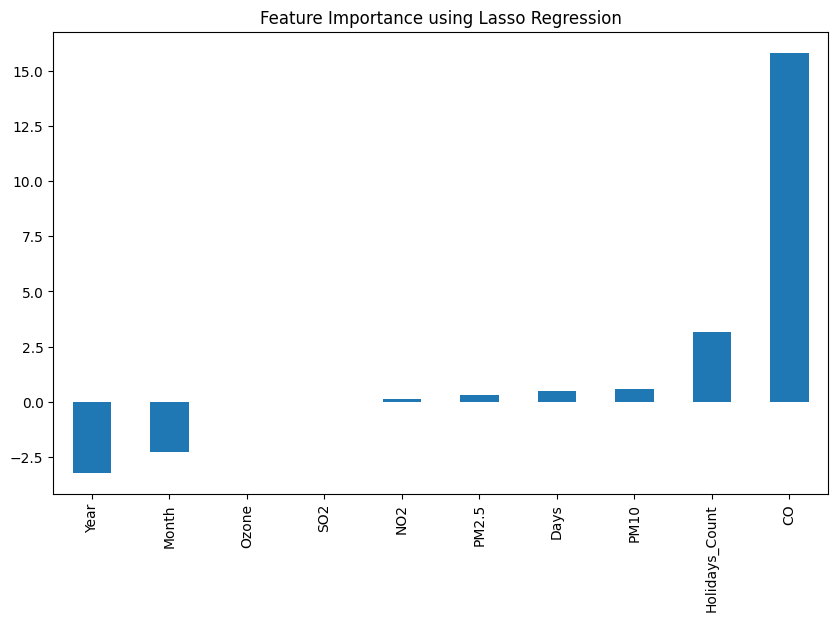

In [87]:
importance = pd.Series(lasso.coef_, index=X.columns)
importance.sort_values().plot(kind='bar', figsize=(10,6))
plt.title("Feature Importance using Lasso Regression")
plt.show()
